In [17]:
# import ---------------------------------------
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 옵션 설정 --------------------------------
# 모든 컬럼 출력
pd.set_option('display.max_columns', None)
# 출력 너비 지정
pd.set_option('display.width', 1000)
# 배경 스타일 설정
sns.set_style('whitegrid')
# 한글 정렬 맞추기
pd.set_option('display.unicode.east_asian_width', True)
# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.tight_layout()
# 그래프 크기 설정
plt.figure(figsize=(15, 15))

color = ['#1e75f5', '#f4b41e', '#b01ef4']
# csv 파일 읽어오기 -----------------------------
user = pd.read_csv('charangData/user.csv', encoding='cp949')
car = pd.read_csv('charangData/car.csv', encoding='cp949')
booking = pd.read_csv('charangData/booking.csv', encoding='cp949')
branch = pd.read_csv('charangData/branch.csv', encoding='cp949')


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

### 1-a. **회원 나이별 예약 & 차종 분포**
#### - **그래프유형**: 원형그래프
#### - **기대효과**: 나이대별 예약점유를 파악하여 차량 신규 입고 시 고려
#### - **항목값**: 나이대(AgeGroup)
#### - **Raw Data**: user / booking

ageGroup
20대         400
30대         643
40대         538
50대         163
60세 이상     54
Name: bookingId, dtype: int64


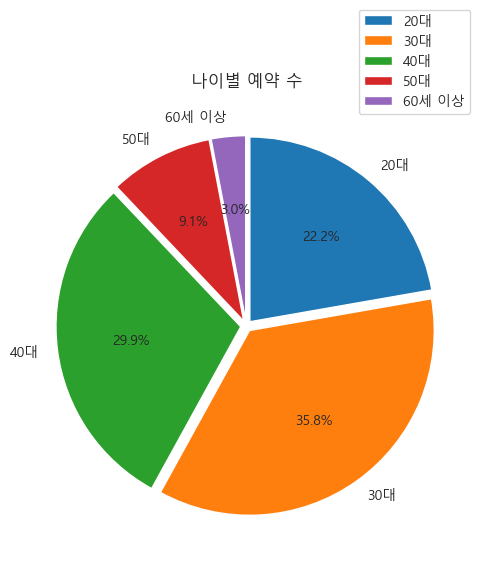

In [18]:
# 회원 나이별 예약 분포
# 결측치 주민등록번호에 대해서 평균값으로
# 전체 user 테이블의 resistNum의 
# 앞자리 두개를 이용해 나이 컬럼 생성 후 삽입
current_year = datetime.datetime.now().year

# 1. 앞 2자리 추출 및 숫자 변환
user['birth_year'] = pd.to_numeric(user['resistNum'].str[:2], errors='coerce')

# 2. 나이 판단 로직 (np.where 사용)
# 조건: 0~7 사이면 2000년대생, 아니면 1900년대생
user['age'] = np.where(
    user['birth_year'] <= 26,
    # 2026년 기준, 26 이하면 2000년대생
    current_year - (2000 + user['birth_year']),
    current_year - (1900 + user['birth_year'])
)
# 3. 나잇대별 그룹화
user['ageGroup'] = (user['age'] // 10).astype(int).astype(str) + '0대'
user.loc[user['age'] >= 60, 'ageGroup'] = '60세 이상'
user = user[user['ageGroup'] != '10대']  # 10대 값 2개 제거
# user['ageGroup'] = user['ageGroup'].replace('10대', '20대')

# 4. 데이터 병합 및 필요한 컬럼만 추출 + 결측치 처리(중간값)
merge01 = pd.merge(user, booking, how='outer', on='userId')
merge01['age'] = merge01['age'].fillna(merge01['age'].mean())
merge01a = merge01[['bookingId', 'ageGroup']]

merge01a
# 5. 나이별 예약 수 카운트
result = merge01a.groupby('ageGroup')['bookingId'].count()

print(result)
# explod 설정
explode = [0.03] * len(result)
# 그래프 크기 설정
plt.figure(figsize=(6, 6))

# 원형그래프
plt.pie(
    result,
    labels=result.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'},
    explode = explode
    # pctdistance=0.8,  # 퍼센트 글자 위치 (0~1 사이)
)
# 가운데 원 추가
# center_circle = plt.Circle((0, 0), 0.6, fc='white')
# plt.gca().add_artist(center_circle)
plt.title('나이별 예약 수')
# 범례 생성
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1.2),
    # ncol=2
)
# plt.legend()
# 그래프 이미지 저장
plt.savefig("age_car_pie.png", dpi=300)
plt.show()

### 1-b. **나이별 예약 차종 그래프**
#### - **그래프유형**: 누적 막대 그래프
#### - **기대효과**: 나이대별 예약수, 차종 분포를 파악하여 차량 신규 입고 시 고려
#### - **x축**: 나이대(AgeGroup)
#### - **x축**: 수(Count)
#### - **Raw Data**: user / booking / car

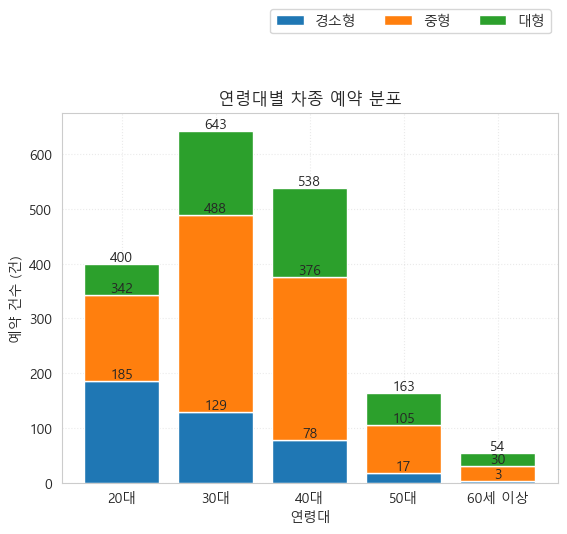

In [19]:
# 회원 나이별 차종 분포
# merge 후 필요한 데이터: carSize, ageGroup

# 데이터 병합 및 필요한 컬럼만 추출 + 결측치 처리(중간값으로)
merge02a = pd.merge(user, booking, how='inner', on='userId')
merge02a['age'] = merge02a['age'].fillna(merge02a['age'].median())
merge02b = pd.merge(merge02a, car, how='outer', on='carId')

# 차량 테이블 머지하기
merge02c = merge02b[['carSize', 'ageGroup']]
merge02c
# 그룹화해서 개수 세기
grouped = merge02c.groupby(['ageGroup', 'carSize']).size()
grouped

# 세로로 된 데이터를 옆으로 펼치기
result02 = grouped.unstack()
x = result02.index

col1 = '경소형'
col2 = '중형'
col3 = '대형'

# 1. 그래프 그리기
plt.bar(x, result02[col1], label=col1)
plt.bar(x, result02[col2], label=col2, bottom=result02[col1])
plt.bar(x, result02[col3], label=col3, bottom=result02[col1] + result02[col2])

# 2. 텍스트 라벨 추가
for i in range(len(result02)):
    # 첫 번째 막대 (경소형) 값
    val1 = result02[col1].iloc[i]
    plt.text(i, val1, int(val1), ha='center', va='bottom')
    # 두 번째 누적 합계 (경소형 + 중형)
    val2 = val1 + result02[col2].iloc[i]
    plt.text(i, val2, int(val2), ha='center', va='bottom')
    # 세 번째 전체 합계 (경소형 + 중형 + 대형)
    val3 = val2 + result02[col3].iloc[i]
    plt.text(i, val3, int(val3), ha='center', va='bottom')


# 4. 그래프 디자인 및 가독성 향상
plt.title('연령대별 차종 예약 분포')
plt.xlabel('연령대')
plt.ylabel('예약 건수 (건)')
# 범례 생성
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1.3),
    ncol=3
)

plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.grid(axis='y', linestyle=':', alpha=0.4)

# 그래프 이미지 저장
plt.savefig("age_car_plot.png", dpi=300, transparent=True)
plt.show()


### 2. **월별 가입자수 추이**
#### - **그래프유형**: 꺾은선 그래프
#### - **기대효과**: 월별 가입차 추이를 통해 유입이 저조한 달의 경우, 대책 기획
#### - **X축**: 월(Month)
#### - **Y축**: 가입자수(Count)
#### - **Raw Data**: user

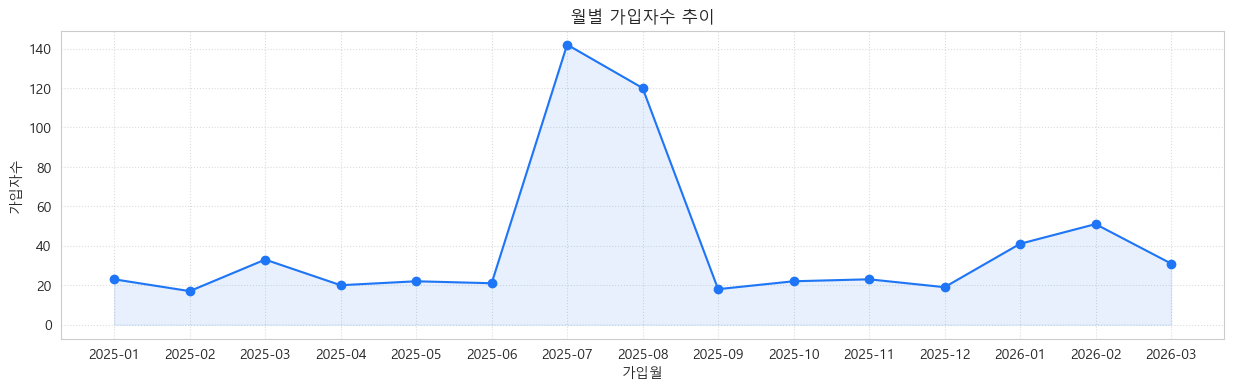

In [20]:
# 결측치 확인
# print(df02.isna().sum())

user['regDate'] = pd.to_datetime(user['regDate'])
user[['name', 'regDate']]

result = user.groupby(user['regDate'].dt.to_period('M')).size().reset_index(name = '가입자수')
result['regDate'] = result['regDate'].astype(str)  # period타입을 문자열로 변환

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(15,4))

# 03. 꺽은선 그래프
plt.plot(result['regDate'], result['가입자수'], marker='o', color='#1e75f5')

# 04. 영역 추가
plt.fill_between(result['regDate'], result['가입자수'], alpha=0.1, color='#1e75f5')

plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# 05. 제목, 라벨 지정
plt.title('월별 가입자수 추이')
plt.xlabel('가입월')
plt.ylabel('가입자수')
plt.savefig("age_car_plot.png", dpi=300, transparent=True)
plt.show()

### 3-a. **월별 예약 횟수 **
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 월별 예약수 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 년/월(Year/Month)
#### - **y축**: 예약수(Count)
#### - **Raw Data**: booking Table

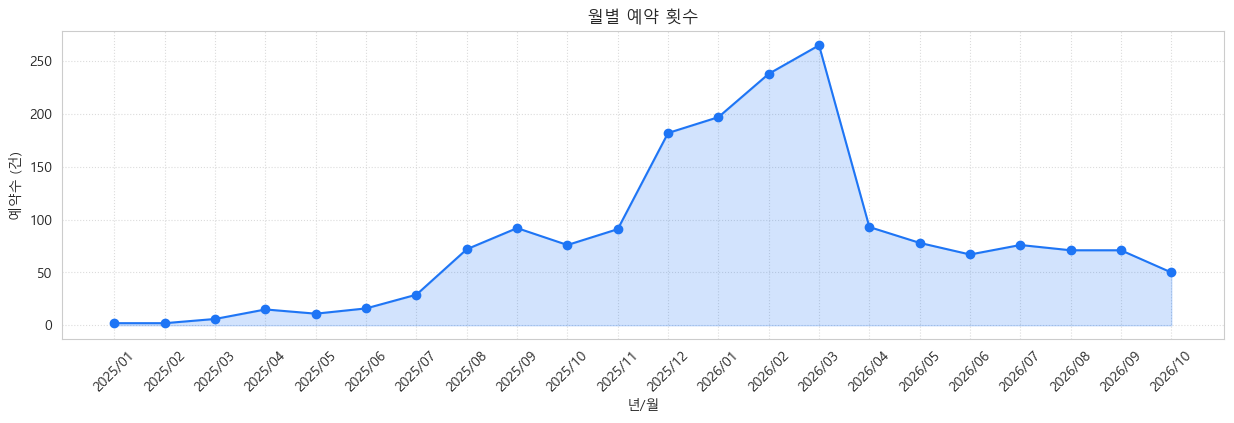

In [21]:
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')

#예약날짜(결제일) 을 데이트타임으로 형변환
booking['startDate'] = pd.to_datetime(booking['startDate'])

#년/월 형식으로 str 가공
booking['년/월'] = booking['startDate'].dt.strftime('%Y/%m')
byMonth = booking.groupby('년/월').size().reset_index(name='예약수')

plt.figure(figsize=(15,4))

bars = plt.plot(byMonth["년/월"],byMonth["예약수"],marker ='o', color='#1e75f5')
plt.fill_between(byMonth['년/월'],byMonth['예약수'], alpha=0.2, color='#1e75f5')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.title("월별 예약 횟수")
plt.xlabel("년/월")
plt.ylabel("예약수 (건)")
plt.xticks(rotation=45)
plt.savefig("reservationByMonth_chart.png",dpi=300)
plt.show()

### 3-b. **월별 매출 추이 **
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 월별 예약 매출 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 년/월(Year/Month))
#### - **y축**: 매출(Price)
#### - **Raw Data**: booking Table

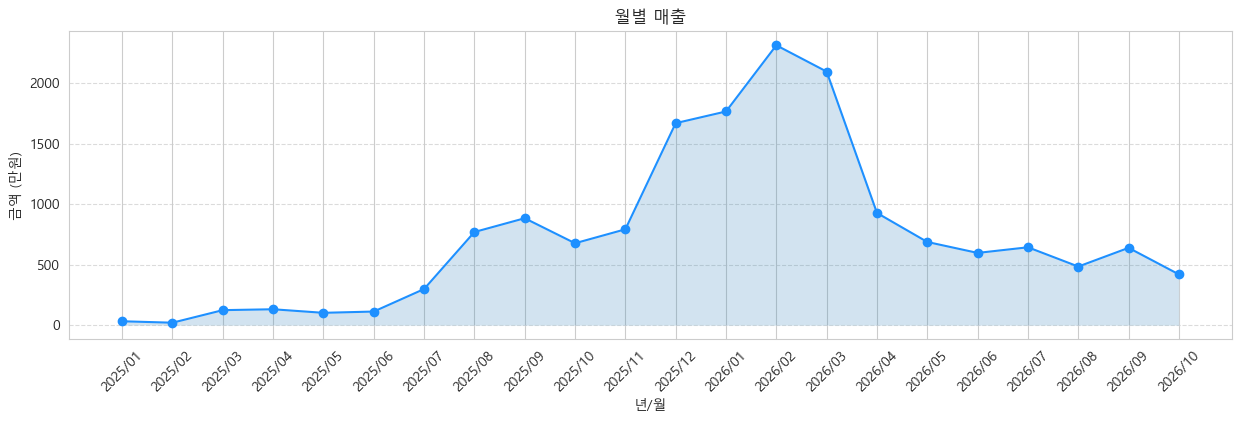

In [22]:
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')

#예약날짜(결제일) 을 데이트타임으로 형변환
booking['bookedDate'] = pd.to_datetime(booking['bookedDate'])


#년/월 형식으로 str 가공
booking['년/월'] = booking['bookedDate'].dt.strftime('%Y/%m')
byMonth = booking.groupby('년/월')['totalPrice'].sum().reset_index()
byMonth['totalPrice'] = byMonth['totalPrice'] / 10000 
# 반드시 한글 깨짐 현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15,4))

bars = plt.plot(byMonth["년/월"],byMonth["totalPrice"],marker ='o' ,color='dodgerblue')
plt.fill_between(byMonth['년/월'],byMonth['totalPrice'], alpha=0.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("월별 매출")
plt.xlabel("년/월")
plt.ylabel("금액 (만원)")
plt.xticks(rotation=45)
plt.savefig("salesByMonth_chart.png",dpi=300)
plt.show()

### 4. **시간대별 차량이용 횟수**
#### - **그래프영문명**: hourly_usage_count
#### - **그래프유형**: 막대 그래프
#### - **기대효과**: 피크타임 시간대 대책 기획 / 장기, 단기 렌트에 대한 기획
#### - **x축**: 시간(Hour)
#### - **x축**: 수(Count)
#### - **Raw Data**: booking

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10520\1000643803.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


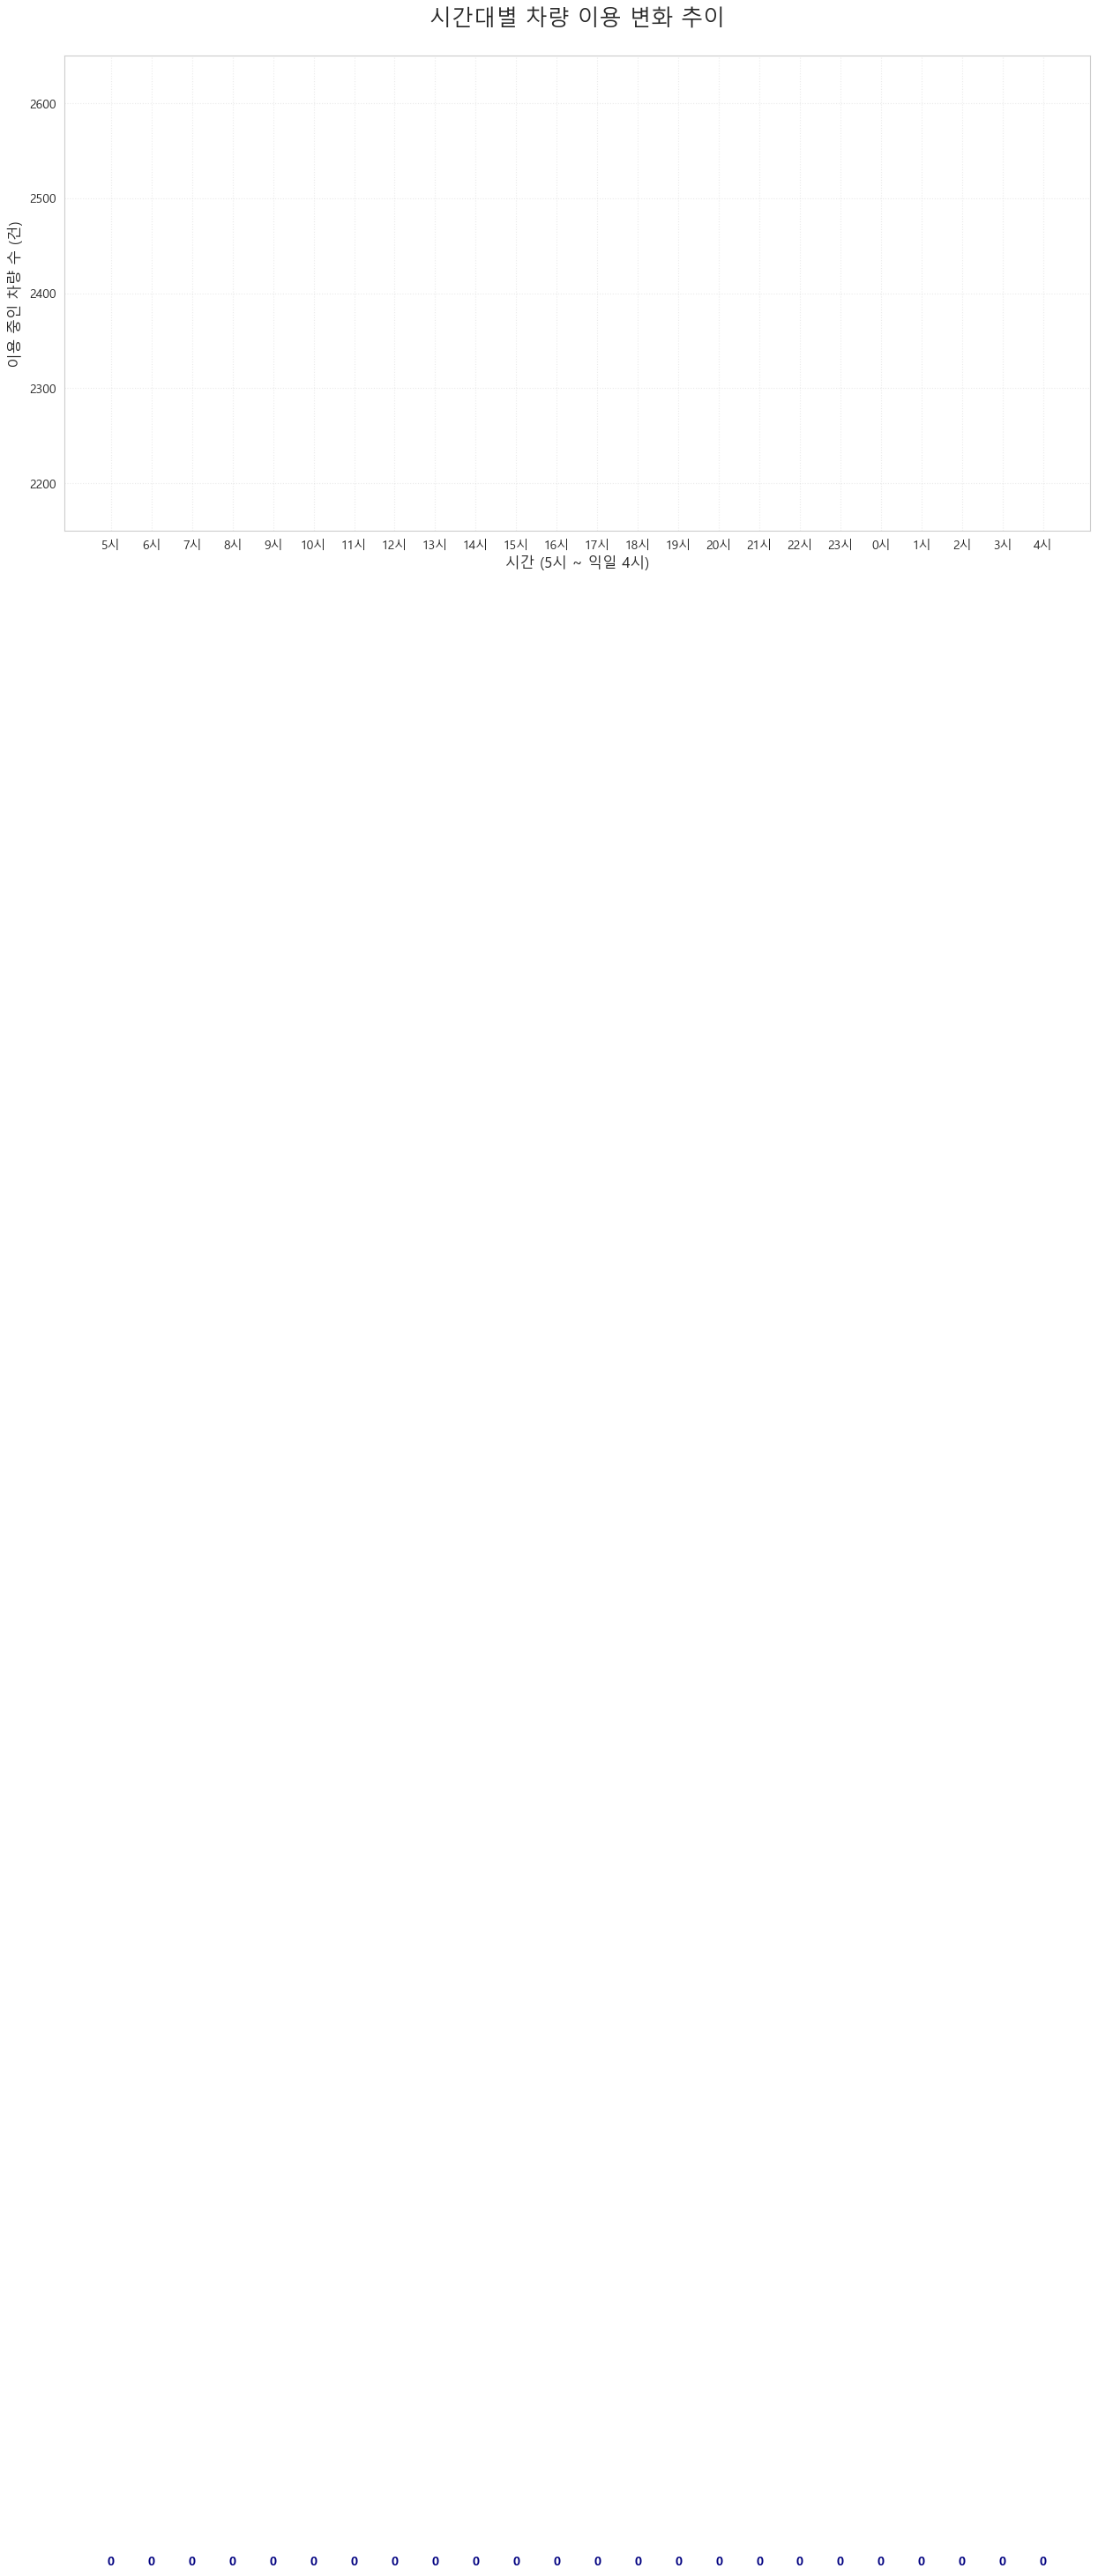

In [23]:
# 1. 데이터 준비 (기존 데이터 사용)
custom_order = list(range(5, 24)) + list(range(0, 5))
x_labels = [f"{h}시" for h in custom_order]
x_axis = np.arange(len(x_labels))

plt.figure(figsize=(15, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 꺾은선 그래프 그리기
# 마커(o)를 추가하고 선 굵기를 조절하여 가독성을 높입니다.
plt.plot(x_axis, ordered_counts, 
         marker='o', 
         markersize=8, 
         linewidth=3, 
         color='dodgerblue', 
         label='이용 차량 수')

# 3. 선 아래 영역 채우기 (그래프가 더 꽉 차 보이고 변화가 뚜렷해짐)
plt.fill_between(x_axis, ordered_counts, 2100, color='skyblue', alpha=0.3)

# 4. y축 범위 설정 (변화를 극대화하기 위해 하한선 조정)
plt.ylim(2150, 2650) 

# 5. 디자인 및 가독성 설정
plt.xticks(x_axis, x_labels)
plt.title('시간대별 차량 이용 변화 추이', fontsize=18, pad=25)
plt.xlabel('시간 (5시 ~ 익일 4시)', fontsize=12)
plt.ylabel('이용 중인 차량 수 (건)', fontsize=12)

# 그리드 설정
plt.grid(True, axis='both', linestyle=':', alpha=0.4)

# 데이터 포인트마다 수치 표시
for i, v in enumerate(ordered_counts):
    plt.text(i, v + 10, int(v), ha='center', fontsize=10, fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig("hourly_usage_count.png", dpi=300, transparent=True)
plt.show()

### 5. **대여(이용)시간 별 예약수**
#### - **그래프유형**: 꺾은선그래프
#### - **기대효과**: 이용 시간 길이 분석을 통한 요금 및 프로모션 전략 최적화
#### - **x축**: 대여(이용)시간(Time)
#### - **y축**: 예약수(Count)
#### - **Raw Data**: booking Table

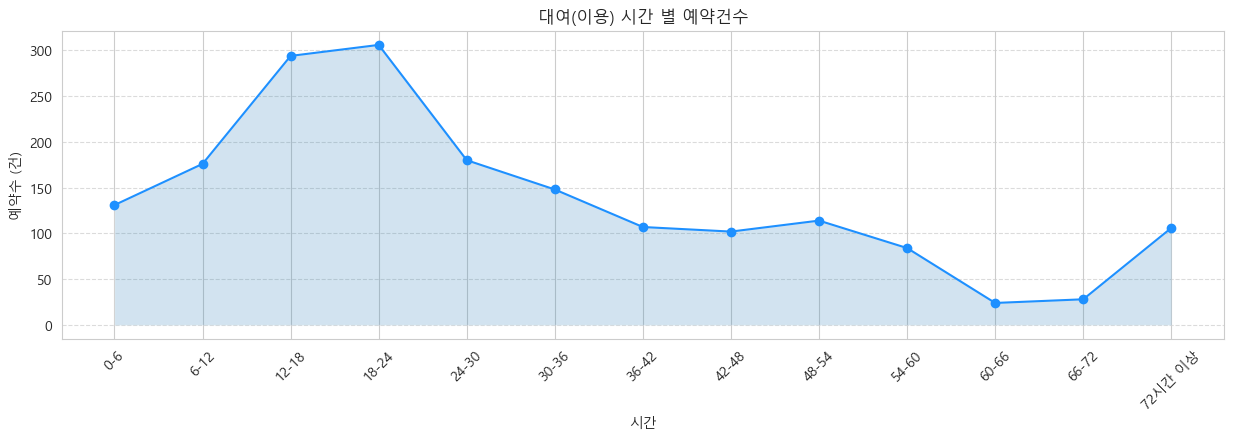

In [24]:
# 대여(이용) 시간 별 예약수를 뽑아내야하므로 booking.csv
booking = pd.read_csv('charangData/booking.csv',encoding='cp949')
bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54,60,66,72,float('inf')]
labels = [
    "0-6", "6-12", "12-18", "18-24",
    "24-30", "30-36", "36-42", "42-48",
    "48-54", "54-60","60-66","66-72","72시간 이상"
]

# 차량 반납시간과 시작시간을  년-월-일-시-분 형태로 가공하여 새로운 필드로 추가(보기 용이하게)
booking['대여시작'] = pd.to_datetime(booking['startDate'] + ' ' + booking['startTime'])
booking['차량반납'] = pd.to_datetime(booking['endDate'] + ' ' + booking['endTime'])

# 차량 반납시간 - 대여시작시간해서 초로하고 시로 나눠서 n시간 형식으로 출력
booking['대여(이용)시간'] = (pd.to_datetime(booking['차량반납']) - pd.to_datetime(booking['대여시작'])).dt.total_seconds() / 3600
# 구간마다 대여(이용)시간을  bin 기준으로 값 비교하여 분할 
booking['대여(이용)시간'] = pd.cut(booking['대여(이용)시간'], bins=bins, labels=labels, right=False   # 0,3 이런식 (3은 다음구간)
)

result = booking['대여(이용)시간'].value_counts().sort_index()
byTime = booking.groupby('대여(이용)시간',observed=False).size().reset_index(name='예약수')

# 반드시 한글 깨짐 현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15,4))

bars = plt.plot(byTime['대여(이용)시간'],byTime["예약수"],marker ='o' ,color='dodgerblue')
plt.fill_between(byTime['대여(이용)시간'],byTime['예약수'], alpha=0.2)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("대여(이용) 시간 별 예약건수")
plt.xlabel("시간")
plt.ylabel("예약수 (건)")
plt.savefig("rentingTime_chart.png",dpi=300)
plt.show()



### 6. **브랜드별 예약 횟수** (brand_reserve_count)
#### - **그래프유형**: 원형그래프
#### - **기대효과**: 추후 들여올 차량 브랜드 선정시 유효
#### - **항목값**: 수(Count)
#### - **Raw Data**: booking Table / car Table

brand
렉사드       87
토유         96
볼바즈      100
제네러스    119
아우디즈    121
DMW         123
빈츠        148
크아        164
한대        215
쉐레보      417
dtype: int64


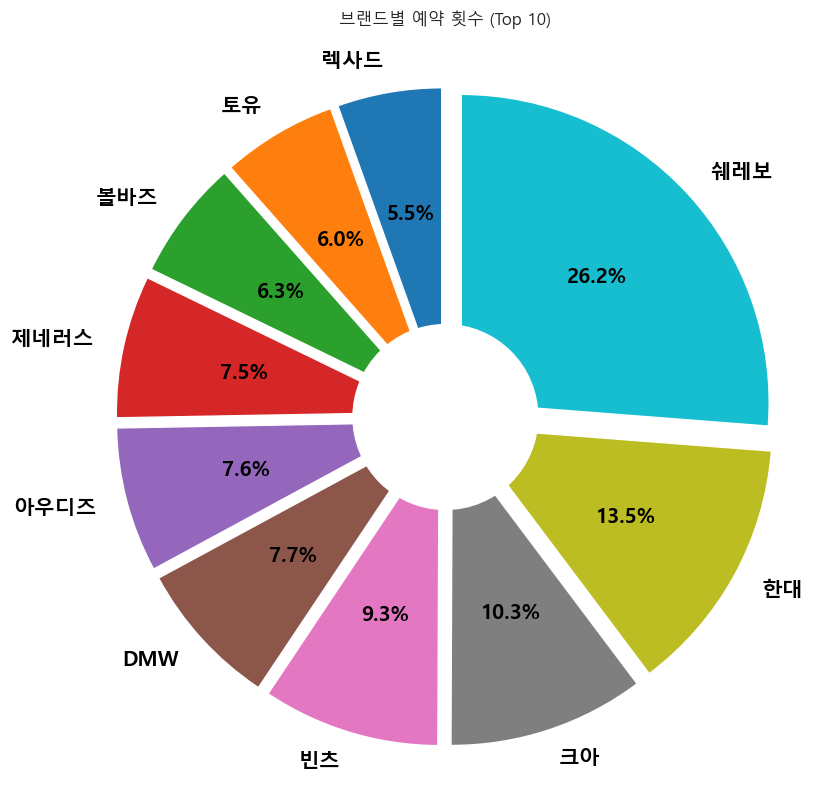

In [25]:
# merge - booking, car
merge06 = pd.merge(booking, car, how='outer', on='carId')
merge06

mer06Cnt = merge06.groupby('brand').size().sort_values(ascending=False).head(10).sort_values(ascending=True)

print(mer06Cnt)

plt.figure(figsize=(10,10))

# plt.pie(mer06Cnt, labels=mer06Cnt.index, autopct='%1.1f%%', startangle=90)
plt.pie(
    mer06Cnt, 
    labels=mer06Cnt.index,
    autopct='%1.1f%%', 
    startangle=90,
    # colors=['#1e75f5', '#0552c6', '#2b7cf7', '#6ca4f8'], 
    wedgeprops={'edgecolor': 'white'}, 
    explode=[0.07] * len(mer06Cnt),
    textprops={
        'fontsize':15,
        'fontweight': 'bold',
        'color': 'black'
   })

cir = plt.Circle((0,0), 0.3, fc='white')
plt.gca().add_artist(cir)

plt.title('브랜드별 예약 횟수 (Top 10)')

plt.savefig('그래프6', transparent=True)  # 투명화 저장

plt.show()

### .7 **차종별(연료타입분리x) 예약 횟수**
#### - **그래프유형**: 막대사탕 차트
#### - **기대효과**: 인기 차량 확인가능. 들여올 차량 선정시 유효
#### - **X축**: 수(Count)
#### - **Raw Data**: booking / car

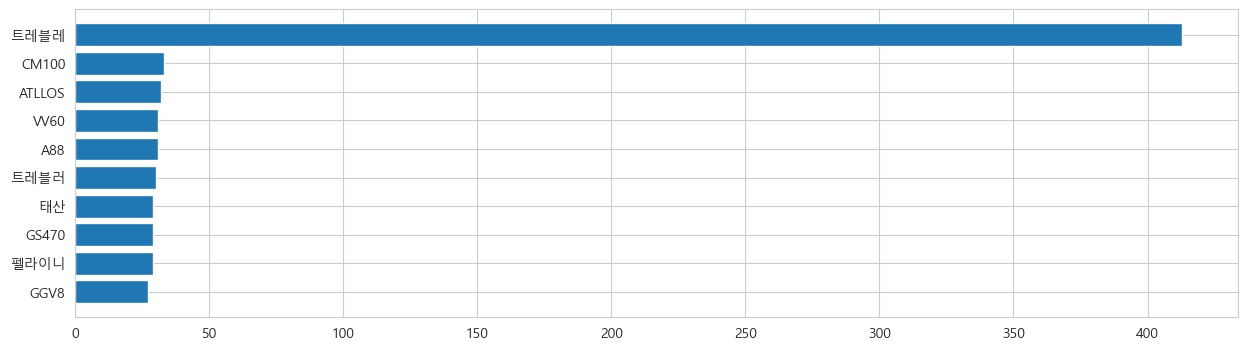

In [26]:
merge07 = pd.merge(booking, car, how='outer', on='carId')
result = merge07.groupby('model').size().sort_values(ascending=False).head(10).sort_values(ascending=True).reset_index(name='예약건수')

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(15, 4))

# 03. 막대그래프
plt.barh(result['model'], result['예약건수'],height=0.8)

# 04.
plt.show()

### 8. **지점별 예약수** (branch_reserve_count)
#### - **그래프유형**: 누적 막대그래프
#### - **기대효과**: 지점별 인기차량? 회원선호도 확인? 가능?
#### - **X축**: 년/월
#### - **Y축**: 지점별 누적 예약수
#### - **Raw Data**: branch Table / car Table / user Table / booking Table

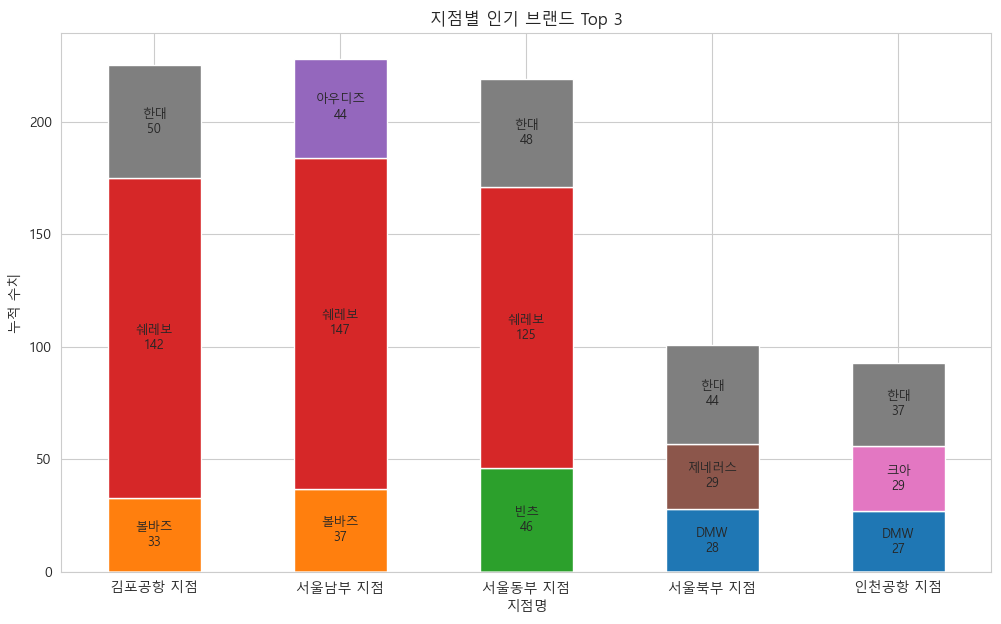

In [27]:
# 1. merge - branch, car
merge08_BranchCar = pd.merge(branch, car, how='outer', on='branchId')
# 2. merge - user, booking
merge08_UserBook = pd.merge(user, booking, how='outer', on='userId')

# 3. merge - merge08_BranchCar, merge08_UserBook
merge08 = pd.merge(merge08_UserBook, merge08_BranchCar, how='inner', on='carId')

# 데이터 집계
counts = merge08.groupby(['name_y', 'brand']).size().reset_index(name='cnt')
top3 = counts.sort_values(['name_y', 'cnt'], ascending=[True, False]).groupby('name_y').head(3)

# 그래프 그리기용 피벗 테이블
table = top3.pivot(index='name_y', columns='brand', values='cnt').fillna(0)

# 그래프 출력
ax = table.plot(kind='bar', stacked=True, figsize=(12, 7), legend=False)

# 항목별 이름(brand)과 수치 표시
# 여기서 'c'는 브랜드별로 쌓인 막대 뭉치라고 생각하면 돼.
for c in ax.containers:
    brand = c.get_label()  # 브랜드 이름 가져오기
    # 각 칸의 중앙에 '브랜드명\n숫자'를 박아준다.
    labels = [f'{brand}\n{int(v)}' if v > 0 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9)

plt.title('지점별 인기 브랜드 Top 3')
plt.xlabel('지점명')
plt.ylabel('누적 수치')

plt.xticks(rotation=0)
# plt.legend(bbox_to_anchor=(1, 1)) # 범례는 밖으로 뺐다.
plt.show()